<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC640 - Data Presentation and Visualization

## **Name:** Tim Hollis

## **Assignment:** Term Project Milestone 3

## **Date:** July 19, 2026

---

**Reference**

U.S. Department of Labor, Women's Bureau. (2024). *National database of childcare prices* [Data set]. https://www.dol.gov/agencies/wb/topics/featured-childcare

</div>

### **Initial Setup**

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker
import seaborn as sns

# Display formatting - no scientific notation, comma-formatted numbers
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)

# Visualization formatting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'sans-serif'

# Colorblind-safe project palette
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
LIGHT_GRAY = '#F2F2F2'
DARK_GRAY = '#333333'
PROJECT_PALETTE = [ROYAL_BLUE, PURPLE, FOREST_GREEN, AMBER]

# Loading dataset
childcare_df = pd.read_excel('nationaldatabaseofchildcareprices.xlsx', engine='calamine')

print(f'✅ Setup complete - all libraries loaded and formatting applied')
print(f'📊 Dataset loaded: {childcare_df.shape[0]:,} rows × {childcare_df.shape[1]:,} columns')

✅ Setup complete - all libraries loaded and formatting applied
📊 Dataset loaded: 34,567 rows × 227 columns


### **Overview**

Milestone 2 established the structure of three mediums aimed at Texas state legislators and staff: a PowerPoint briefing deck, a Power BI dashboard for self-serve county lookups, and a one-page infographic leave-behind. This milestone replaces the placeholder mock-ups with first drafts driven by the actual data. A single preparation cell computes every statistic the mediums share, so all three stay numerically consistent, which was the core design commitment carried over from Milestone 2. The corrected affordability calculation from Milestone 1, nominal prices measured against nominal income, is used throughout.

### **Data Preparation**

One cell computes every number the three mediums need: the corrected national trend, the 2018 county distribution, the second-earner math, and the Texas and Bexar County spotlight values. Each medium reads from these shared variables so no statistic can drift between formats.

In [2]:
# Select and rename the fields the mediums need
working_columns = {
    'State_Name': 'state',
    'State_Abbreviation': 'state_abbr',
    'County_Name': 'county',
    'County_FIPS_Code': 'fips',
    'StudyYear': 'year',
    'MCInfant': 'center_infant_weekly',
    'MCPreschool': 'center_preschool_weekly',
    'MHI': 'nominal_income',
    'FME': 'female_earnings_nominal'
}
story_df = childcare_df[list(working_columns.keys())].rename(columns=working_columns)

# Affordability - nominal prices against nominal income (Milestone 1 correction)
afford_df = story_df.dropna(subset=['center_infant_weekly', 'nominal_income']).copy()
afford_df['annual_infant_cost'] = afford_df['center_infant_weekly'] * 52
afford_df['income_share'] = afford_df['annual_infant_cost'] / afford_df['nominal_income'] * 100

# Corrected national trend of median county burden
trend = afford_df.groupby('year')['income_share'].median()

# 2018 snapshot for the distribution story
hist_2018 = afford_df[afford_df['year'] == 2018].copy()
counties_below = int((hist_2018['income_share'] <= 7).sum())
counties_total = len(hist_2018)
pct_affordable = counties_below / counties_total * 100
median_share_2018 = hist_2018['income_share'].median()

# Second-earner math against female median earnings
earn_2018 = hist_2018.dropna(subset=['center_preschool_weekly', 'female_earnings_nominal']).copy()
earn_2018['annual_preschool_cost'] = earn_2018['center_preschool_weekly'] * 52
earn_2018['one_child_share'] = earn_2018['annual_infant_cost'] / earn_2018['female_earnings_nominal'] * 100
earn_2018['two_child_share'] = ((earn_2018['annual_infant_cost'] + earn_2018['annual_preschool_cost'])
                                / earn_2018['female_earnings_nominal'] * 100)
one_child_median = earn_2018['one_child_share'].median()
two_child_median = earn_2018['two_child_share'].median()

# Texas statewide values for the Texas-first framing
tx_2018 = hist_2018[hist_2018['state_abbr'] == 'TX']
tx_counties_below = int((tx_2018['income_share'] <= 7).sum())
tx_counties_total = len(tx_2018)
tx_median_share = tx_2018['income_share'].median()


# Texas and Bexar County spotlight
texas_2018 = earn_2018[earn_2018['state_abbr'] == 'TX']
texas_trend = afford_df[afford_df['state_abbr'] == 'TX'].groupby('year')['income_share'].median()
tx_one_child = texas_2018['one_child_share'].median()
tx_two_child = texas_2018['two_child_share'].median()
bexar = texas_2018[texas_2018['county'] == 'Bexar County'].iloc[0]

print(f'✅ Shared statistics computed from {len(afford_df):,} county-years')
print(f'📈 Corrected national trend: {trend.loc[2008]:.1f}% (2008) → {trend.loc[2018]:.1f}% (2018)')
print(f'📊 2018 distribution: {counties_below} of {counties_total:,} counties at or below 7% ({pct_affordable:.1f}%)')
print(f'📊 2018 median county burden: {median_share_2018:.1f}% of household income')
print(f'👶 Second-earner math: one child {one_child_median:.1f}% | two children {two_child_median:.1f}% of female median earnings')
print(f'🗓 Texas years with data: {sorted(texas_trend.index.tolist())}')
tx_first, tx_last = int(texas_trend.index.min()), int(texas_trend.index.max())
print(f'🤠 Texas 2018: {len(texas_2018):,} counties | trend {texas_trend.loc[tx_first]:.1f}% ({tx_first}) → {texas_trend.loc[tx_last]:.1f}% ({tx_last})')
print(f'🎯 Texas counties at or below 7% in 2018: {tx_counties_below} of {tx_counties_total}')
print(f'📍 Bexar County: ${bexar["annual_infant_cost"]:,.0f}/year | {bexar["one_child_share"]:.1f}% of female median earnings')

✅ Shared statistics computed from 23,593 county-years
📈 Corrected national trend: 15.4% (2008) → 16.1% (2018)
📊 2018 distribution: 4 of 2,360 counties at or below 7% (0.2%)
📊 2018 median county burden: 16.1% of household income
👶 Second-earner math: one child 33.2% | two children 61.1% of female median earnings
🗓 Texas years with data: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
🤠 Texas 2018: 254 counties | trend 13.3% (2009) → 14.5% (2018)
🎯 Texas counties at or below 7% in 2018: 0 of 254
📍 Bexar County: $8,666/year | 33.1% of female median earnings


### **Medium 1: PowerPoint Briefing Deck Draft**

The ten-slide structure from Milestone 2 is unchanged; the placeholder blocks are now rendered with actual data. Each slide is drawn as a 16:9 page with a claim-style title, one idea, and one visual. Slides render in sequence below exactly as they will appear in the final deck.

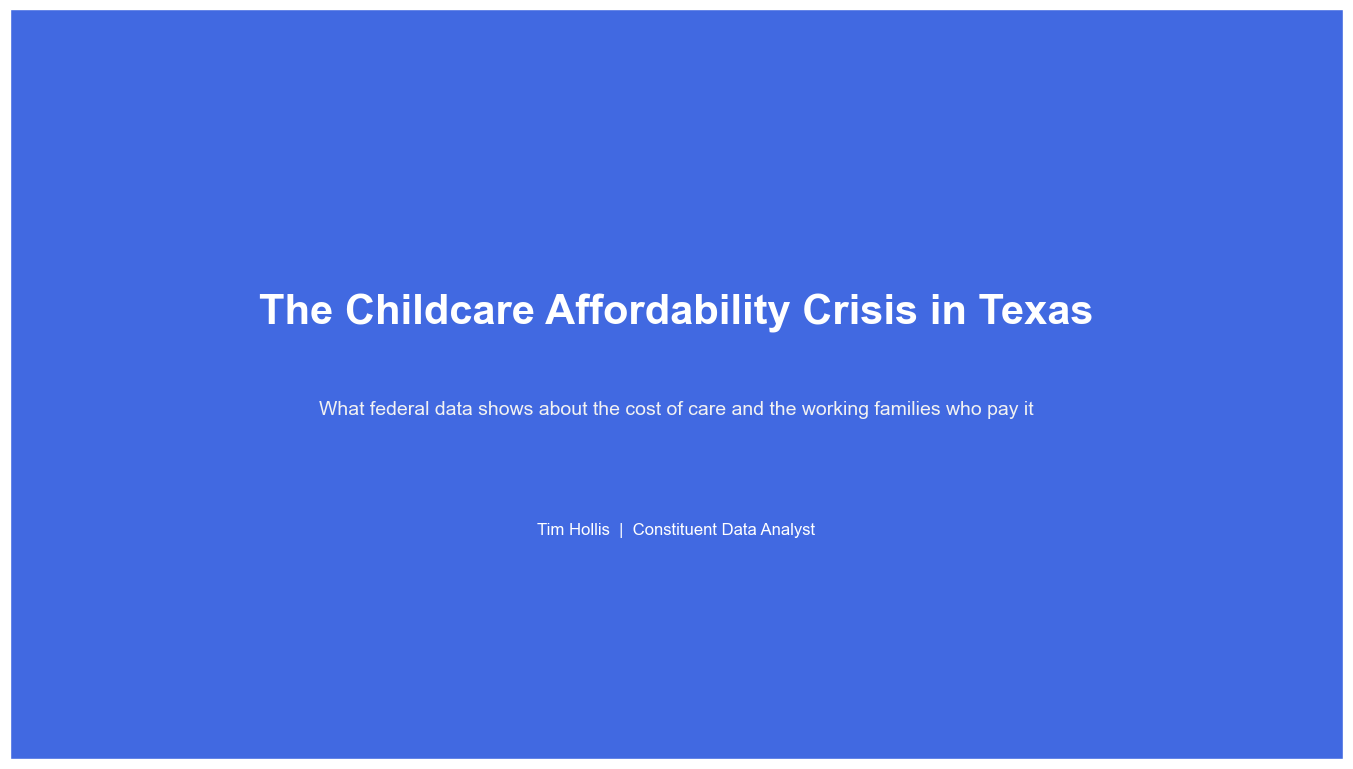

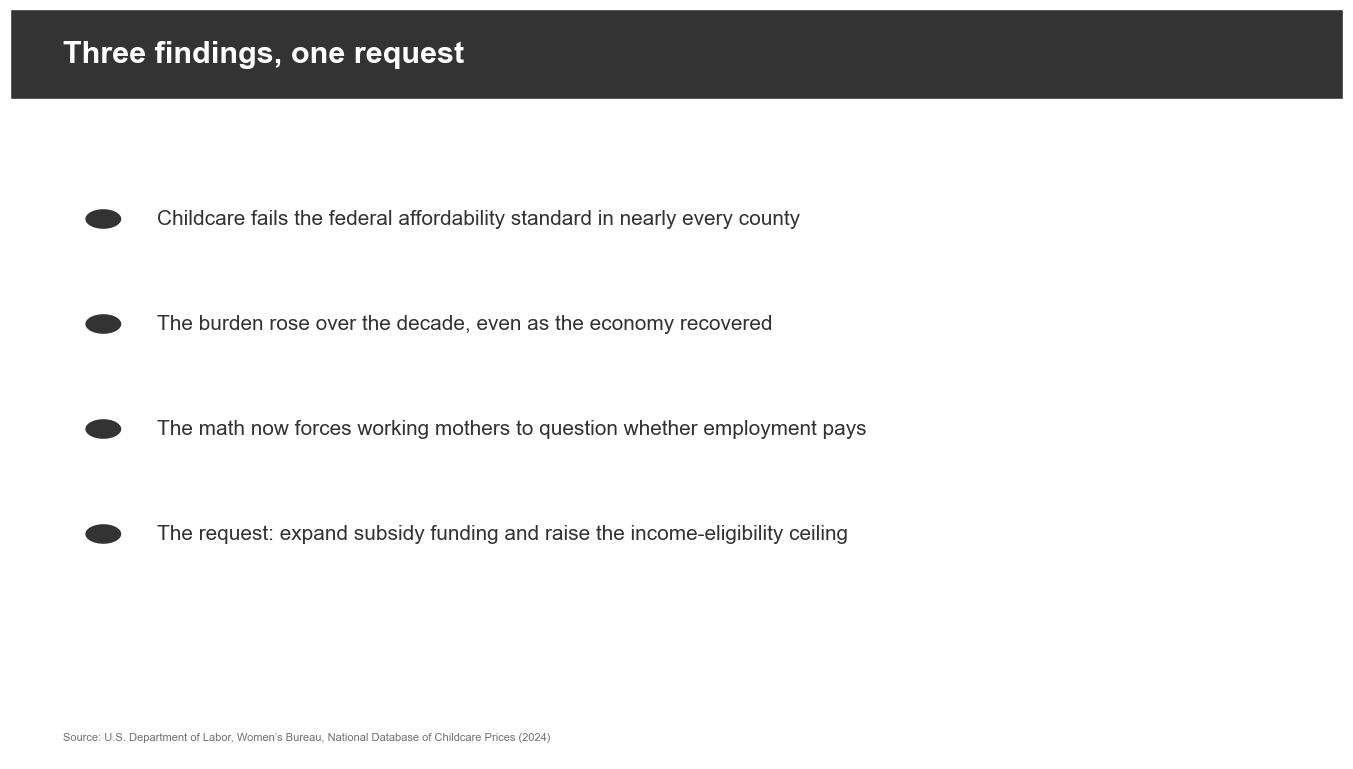

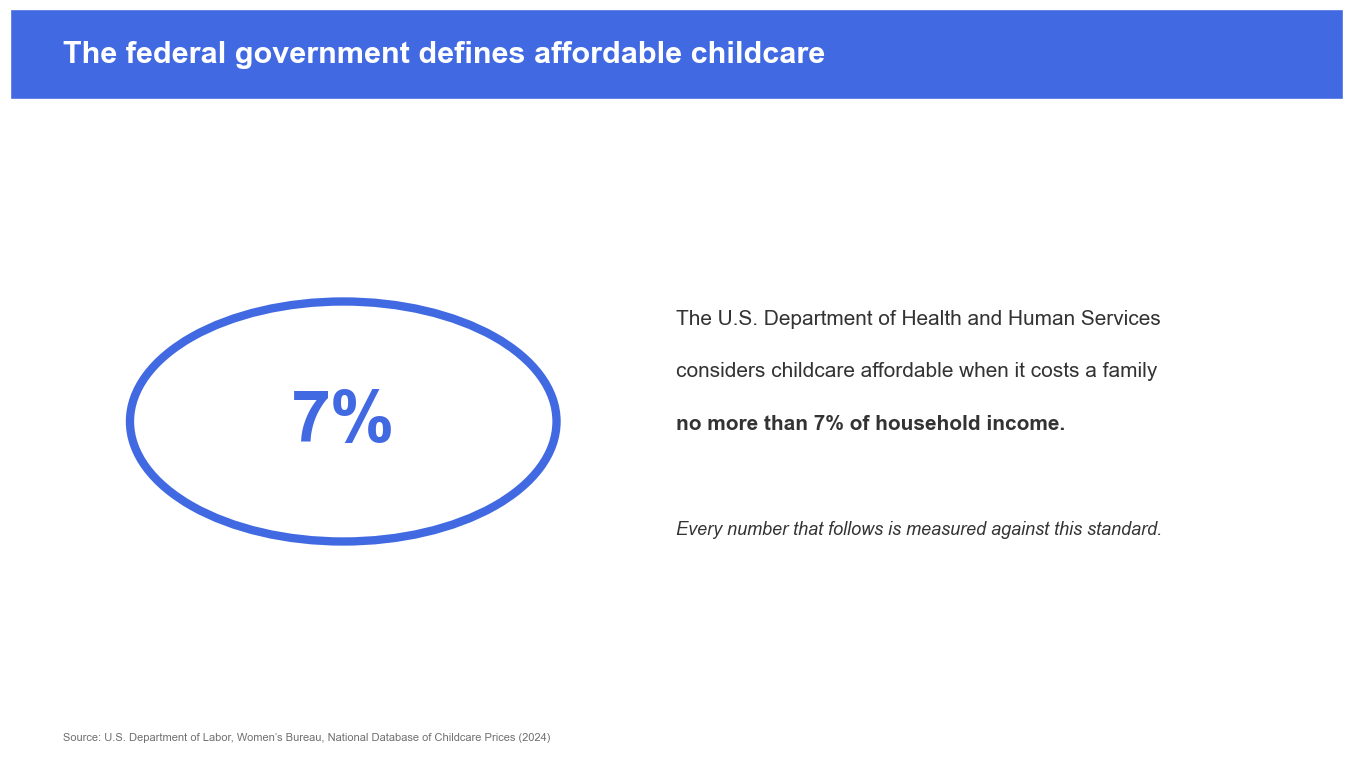

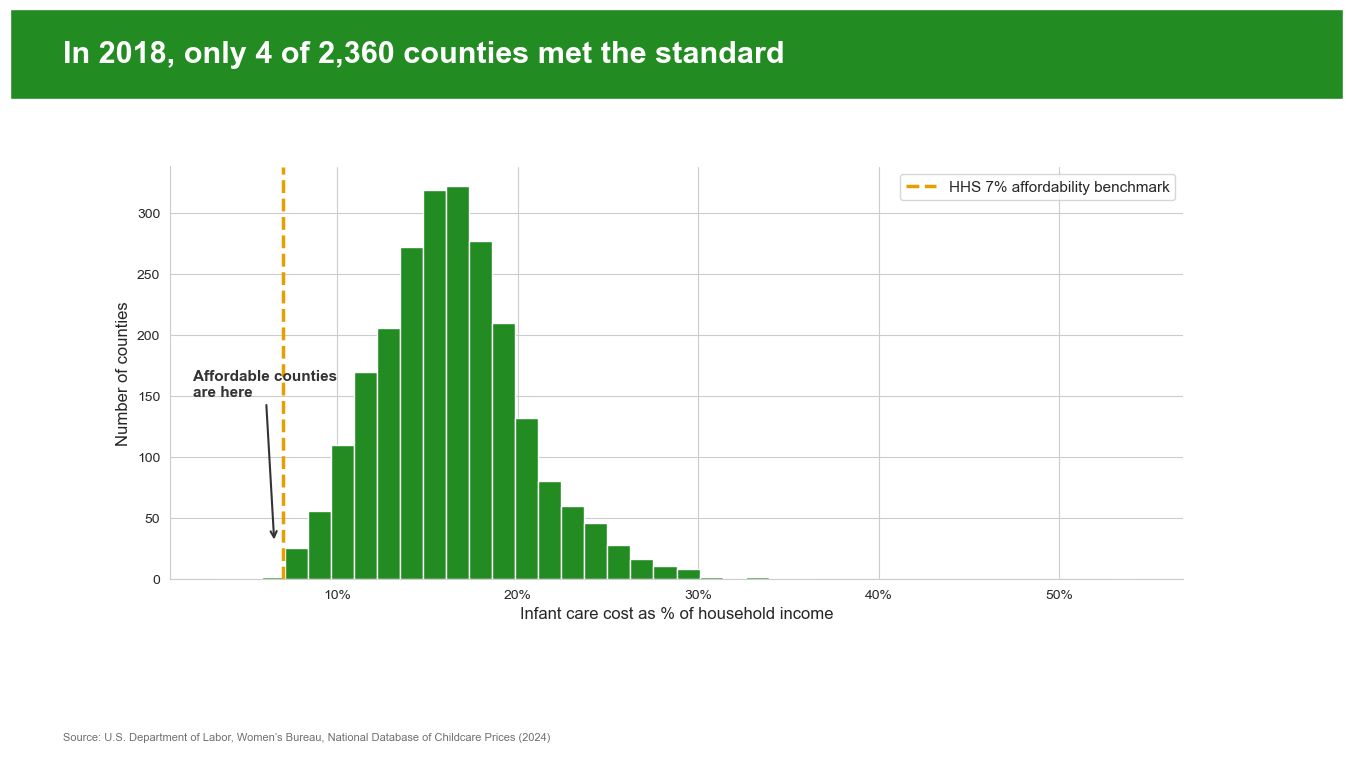

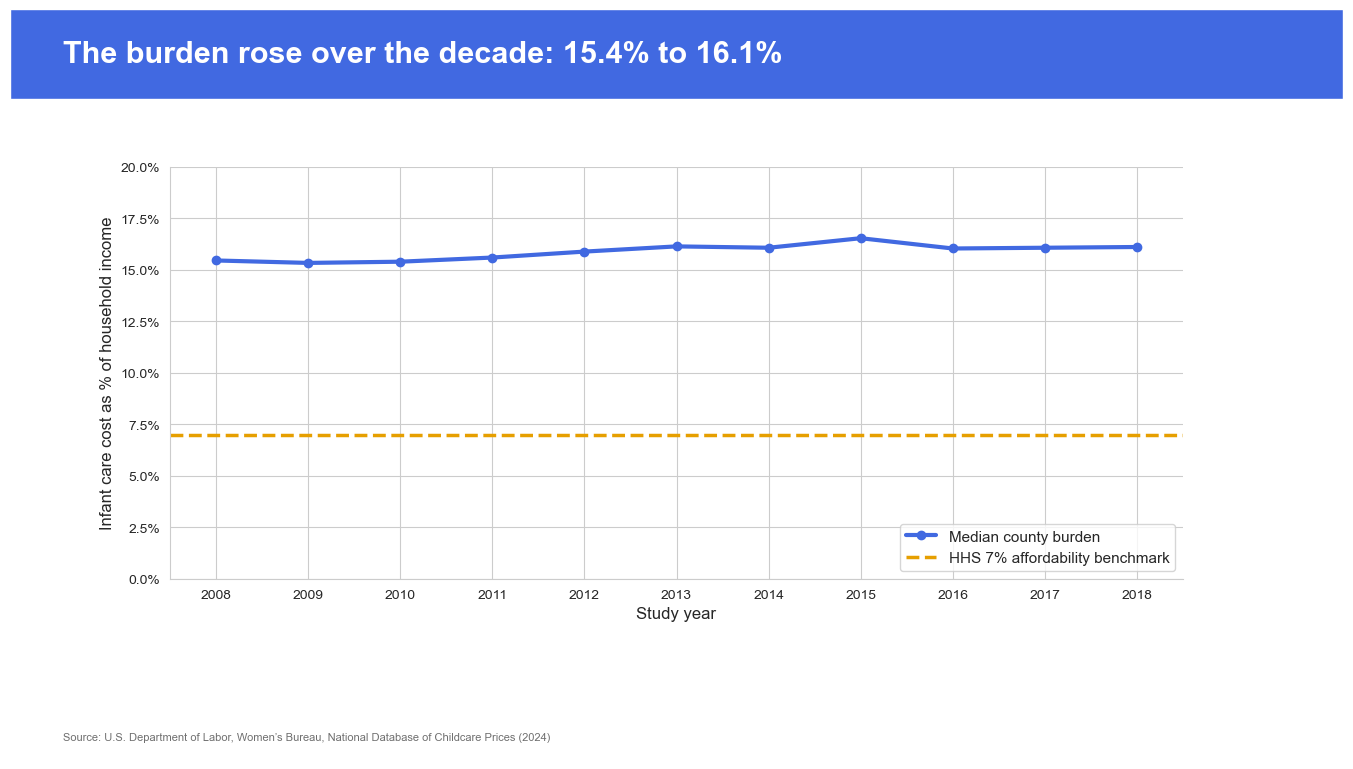

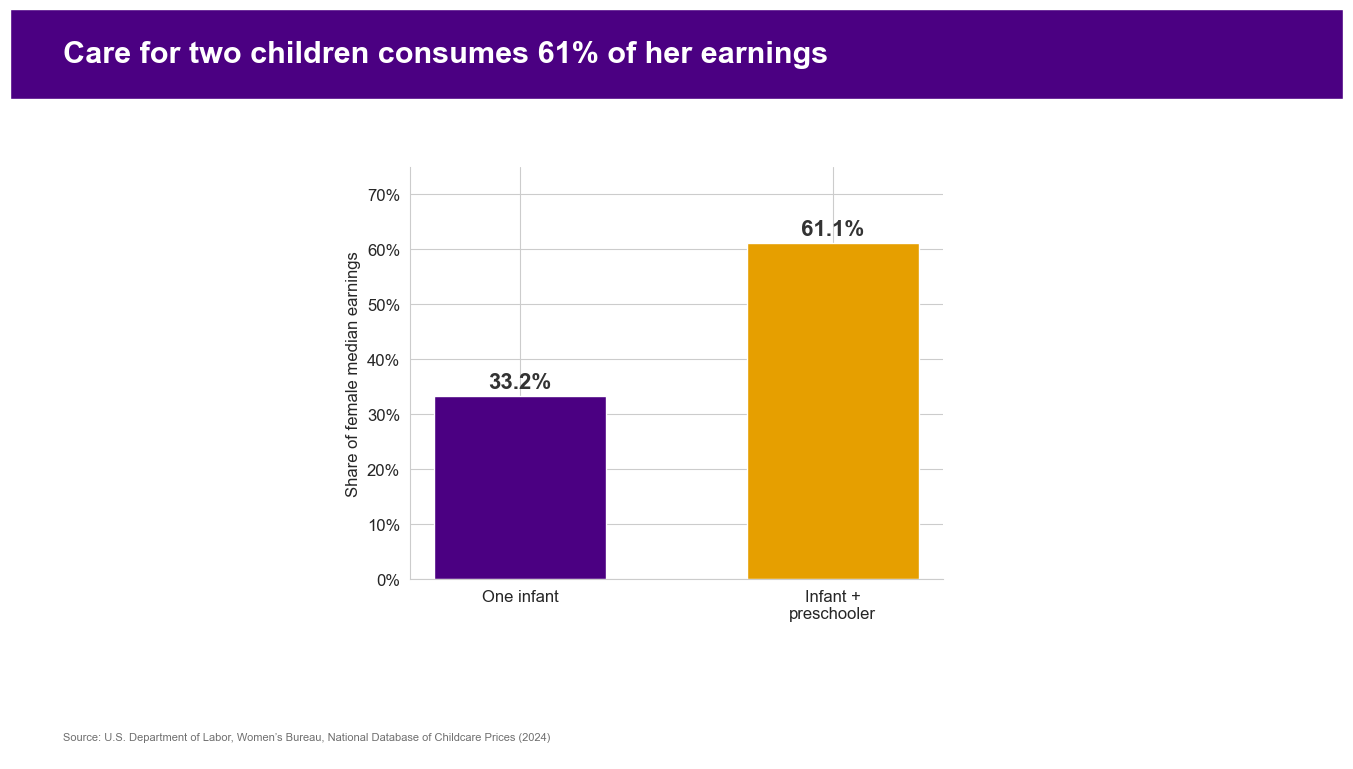

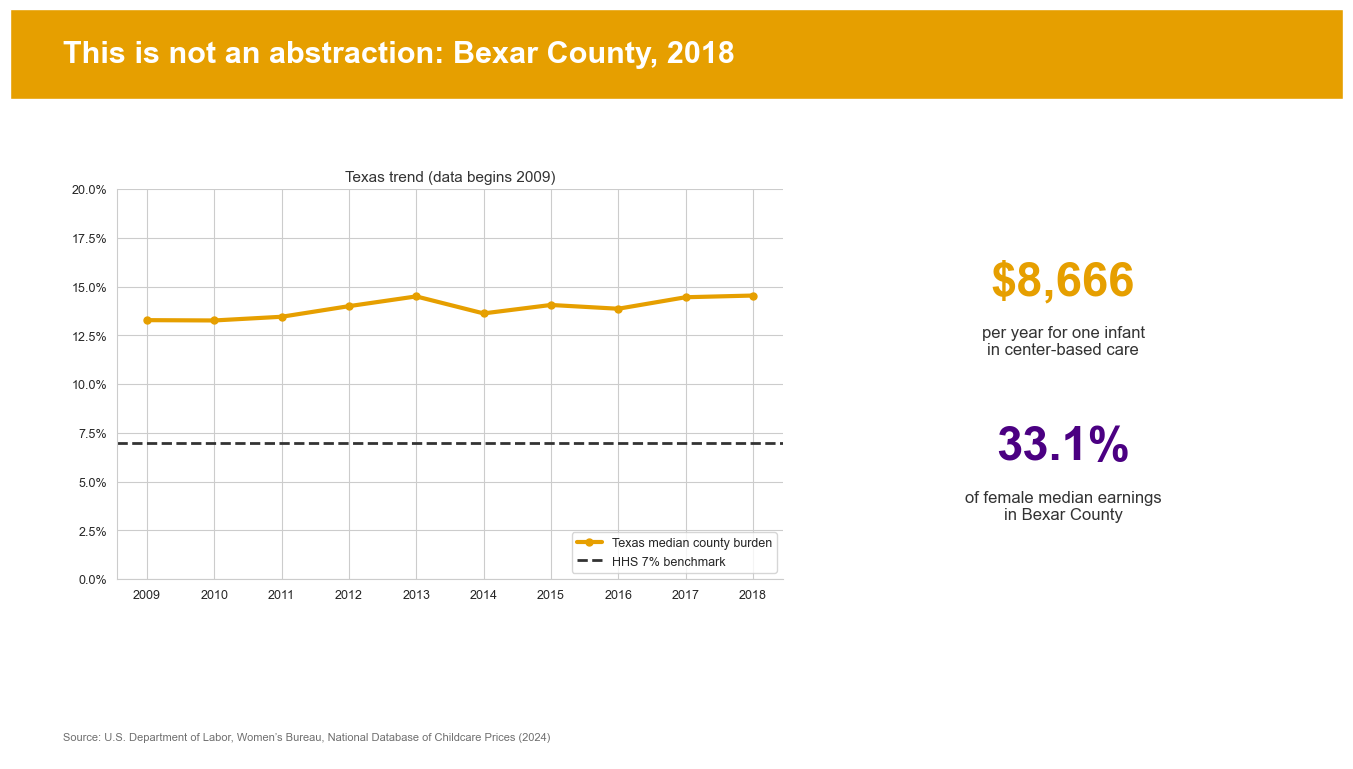

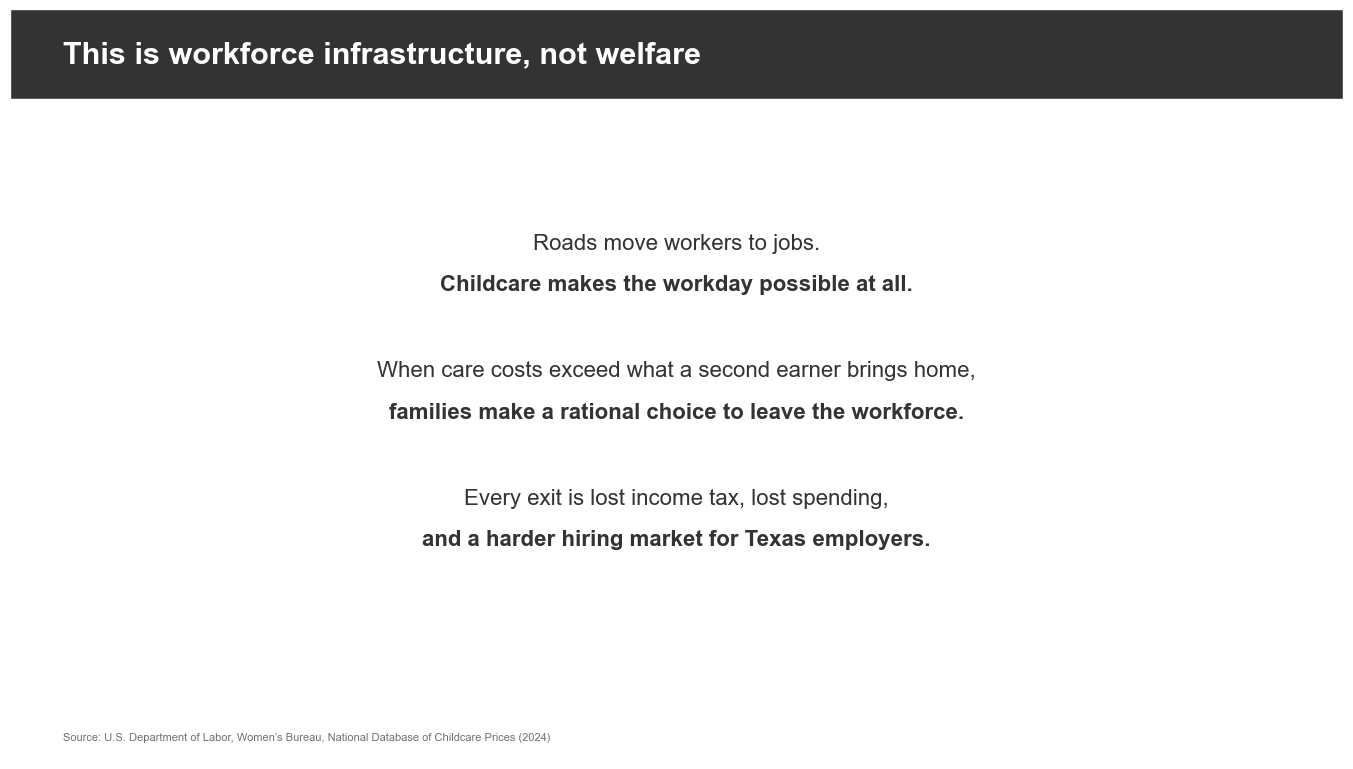

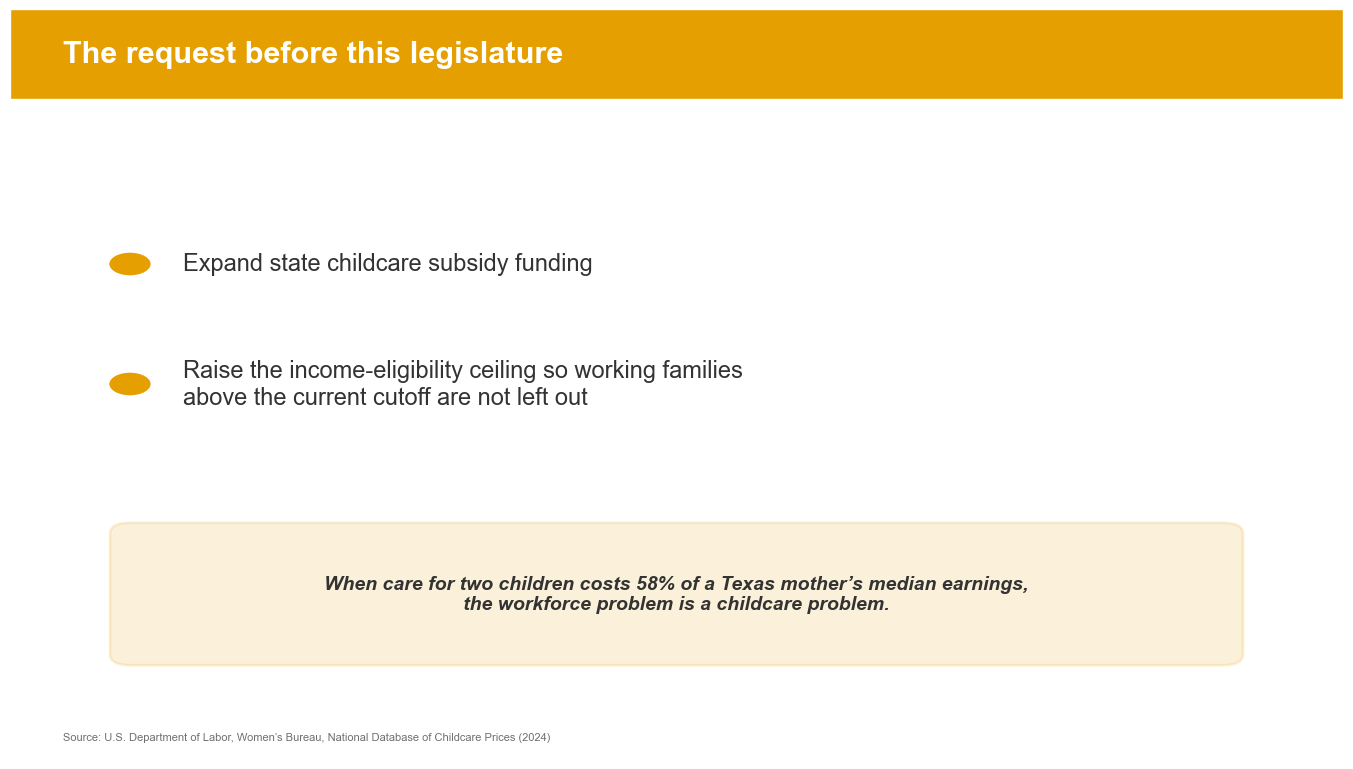

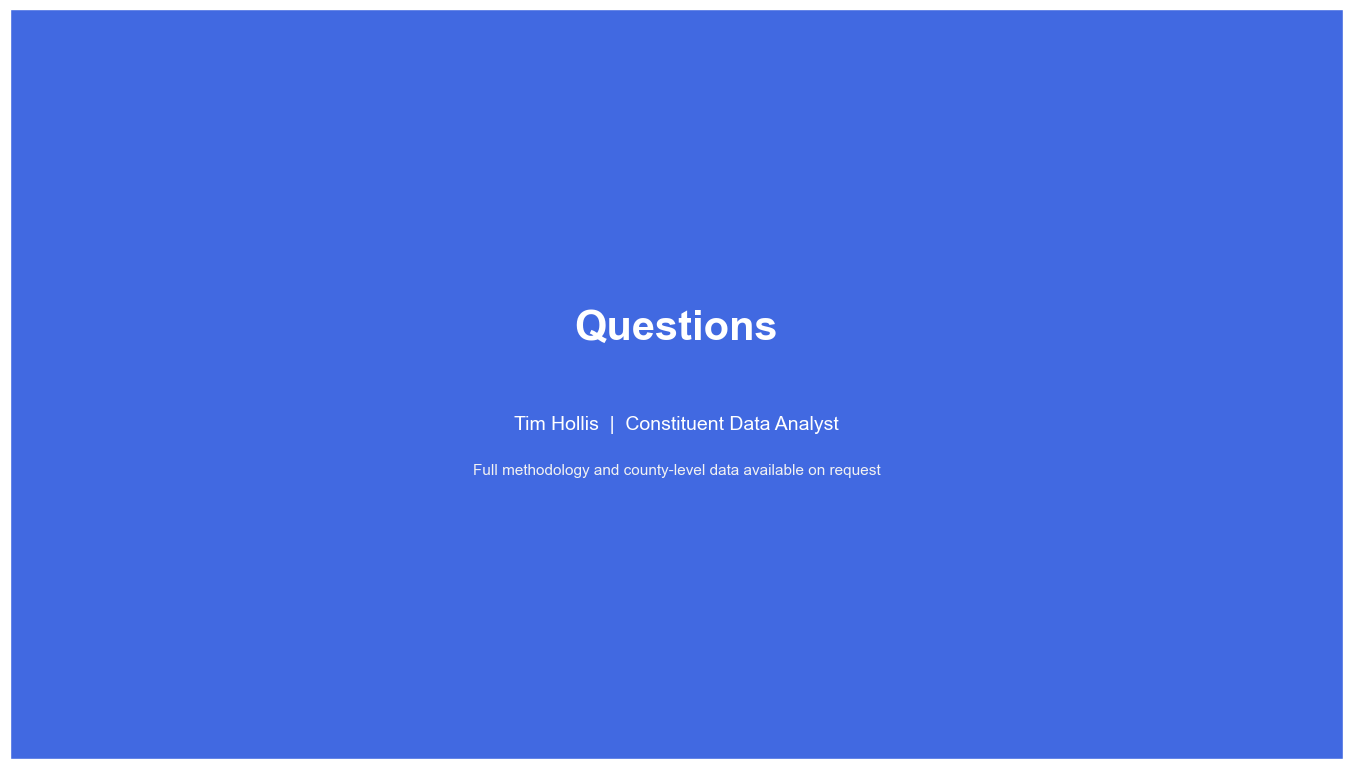

In [3]:
# Helper function for slide creation
def new_slide(accent, title_text, footer=True):
    """Creates a 16:9 slide figure with accent title bar and source footer"""
    fig = plt.figure(figsize=(13.33, 7.5))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(patches.Rectangle((0, 0.88), 1, 0.12, facecolor=accent))
    ax.text(0.04, 0.94, title_text, ha='left', va='center', fontsize=22,
            fontweight='bold', color='white')
    if footer:
        ax.text(0.04, 0.025, 'Source: U.S. Department of Labor, Women\u2019s Bureau, National Database of Childcare Prices (2024)',
                fontsize=8, color=DARK_GRAY, alpha=0.7)
    return fig, ax

# Slide 1: Title
fig, ax = new_slide(ROYAL_BLUE, '', footer=False)
ax.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor=ROYAL_BLUE))
ax.text(0.5, 0.58, 'The Childcare Affordability Crisis in Texas', ha='center',
        fontsize=30, fontweight='bold', color='white')
ax.text(0.5, 0.46, 'What federal data shows about the cost of care and the working families who pay it',
        ha='center', fontsize=14, color=LIGHT_GRAY)
ax.text(0.5, 0.3, 'Tim Hollis  |  Constituent Data Analyst', ha='center',
        fontsize=12, color='white')
plt.show()

# Slide 2: Roadmap
fig, ax = new_slide(DARK_GRAY, 'Three findings, one request')
roadmap = [
    'Childcare fails the federal affordability standard in nearly every county',
    'The burden rose over the decade, even as the economy recovered',
    'The math now forces working mothers to question whether employment pays',
    'The request: expand subsidy funding and raise the income-eligibility ceiling'
]
for i, item in enumerate(roadmap):
    y = 0.72 - i * 0.14
    ax.add_patch(patches.Circle((0.07, y), 0.014, facecolor=DARK_GRAY))
    ax.text(0.11, y, item, ha='left', va='center', fontsize=15, color=DARK_GRAY)
plt.show()

# Slide 3: The 7% Standard
fig, ax = new_slide(ROYAL_BLUE, 'The federal government defines affordable childcare')
ax.add_patch(patches.Circle((0.25, 0.45), 0.16, facecolor='none',
                            edgecolor=ROYAL_BLUE, linewidth=6))
ax.text(0.25, 0.45, '7%', ha='center', va='center', fontsize=52,
        fontweight='bold', color=ROYAL_BLUE)
ax.text(0.5, 0.58, 'The U.S. Department of Health and Human Services', fontsize=15, color=DARK_GRAY)
ax.text(0.5, 0.51, 'considers childcare affordable when it costs a family', fontsize=15, color=DARK_GRAY)
ax.text(0.5, 0.44, 'no more than 7% of household income.', fontsize=15, fontweight='bold', color=DARK_GRAY)
ax.text(0.5, 0.3, 'Every number that follows is measured against this standard.',
        fontsize=13, style='italic', color=DARK_GRAY)
plt.show()

# Slide 4: Almost No County Qualifies (2018 distribution)
fig, ax = new_slide(FOREST_GREEN, 'In 2018, only 4 of 2,360 counties met the standard')
ax_chart = fig.add_axes([0.12, 0.24, 0.76, 0.55])
ax_chart.hist(hist_2018['income_share'], bins=40, color=FOREST_GREEN, edgecolor='white')
ax_chart.axvline(7, color=AMBER, linestyle='--', linewidth=2.5, label='HHS 7% affordability benchmark')
ax_chart.set_xlabel('Infant care cost as % of household income', fontsize=12)
ax_chart.set_ylabel('Number of counties', fontsize=12)
ax_chart.xaxis.set_major_formatter(mticker.PercentFormatter())
ax_chart.legend(fontsize=11, loc='upper right')
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax_chart.annotate('Affordable counties\nare here', xy=(6.5, 30), xytext=(2, 150),
                  fontsize=11, color=DARK_GRAY, fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color=DARK_GRAY, linewidth=1.5))
plt.show()

# Slide 5: The Burden Rose Over a Decade (corrected trend)
fig, ax = new_slide(ROYAL_BLUE, 'The burden rose over the decade: 15.4% to 16.1%')
ax_chart = fig.add_axes([0.12, 0.24, 0.76, 0.55])
ax_chart.plot(trend.index, trend.values, color=ROYAL_BLUE, linewidth=3,
              marker='o', markersize=6, label='Median county burden')
ax_chart.axhline(7, color=AMBER, linestyle='--', linewidth=2.5, label='HHS 7% affordability benchmark')
ax_chart.set_xlabel('Study year', fontsize=12)
ax_chart.set_ylabel('Infant care cost as % of household income', fontsize=12)
ax_chart.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_chart.set_ylim(0, 20)
ax_chart.set_xticks(trend.index)
ax_chart.legend(fontsize=11, loc='lower right')
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
plt.show()

# Slide 6: The Second-Earner Math
fig, ax = new_slide(PURPLE, 'Care for two children consumes 61% of her earnings')
ax_chart = fig.add_axes([0.3, 0.24, 0.4, 0.55])
categories = ['One infant', 'Infant +\npreschooler']
values = [one_child_median, two_child_median]
bars = ax_chart.bar(categories, values, color=[PURPLE, AMBER], width=0.55)
for bar, v in zip(bars, values):
    ax_chart.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f'{v:.1f}%',
                  ha='center', fontsize=16, fontweight='bold', color=DARK_GRAY)
ax_chart.set_ylabel('Share of female median earnings', fontsize=12)
ax_chart.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_chart.set_ylim(0, 75)
ax_chart.tick_params(labelsize=12)
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
plt.show()

# Slide 7: Texas Spotlight - Bexar County
fig, ax = new_slide(AMBER, 'This is not an abstraction: Bexar County, 2018')
ax_chart = fig.add_axes([0.08, 0.24, 0.5, 0.52])
ax_chart.plot(texas_trend.index, texas_trend.values, color=AMBER, linewidth=3,
              marker='o', markersize=5, label='Texas median county burden')
ax_chart.axhline(7, color=DARK_GRAY, linestyle='--', linewidth=2, label='HHS 7% benchmark')
ax_chart.set_ylim(0, 20)
ax_chart.set_xticks(texas_trend.index)
ax_chart.tick_params(labelsize=9)
ax_chart.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_chart.set_title('Texas trend (data begins 2009)', fontsize=11, color=DARK_GRAY)
ax_chart.legend(fontsize=9, loc='lower right')
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax.text(0.79, 0.62, f'${bexar["annual_infant_cost"]:,.0f}', ha='center',
        fontsize=34, fontweight='bold', color=AMBER)
ax.text(0.79, 0.54, 'per year for one infant\nin center-based care', ha='center',
        fontsize=12, color=DARK_GRAY)
ax.text(0.79, 0.4, f'{bexar["one_child_share"]:.1f}%', ha='center',
        fontsize=34, fontweight='bold', color=PURPLE)
ax.text(0.79, 0.32, 'of female median earnings\nin Bexar County', ha='center',
        fontsize=12, color=DARK_GRAY)
plt.show()

# Slide 8: Infrastructure, Not Welfare
fig, ax = new_slide(DARK_GRAY, 'This is workforce infrastructure, not welfare')
reframe = [
    ('Roads move workers to jobs.', 'Childcare makes the workday possible at all.'),
    ('When care costs exceed what a second earner brings home,', 'families make a rational choice to leave the workforce.'),
    ('Every exit is lost income tax, lost spending,', 'and a harder hiring market for Texas employers.')
]
for i, (line1, line2) in enumerate(reframe):
    y = 0.68 - i * 0.17
    ax.text(0.5, y, line1, ha='center', fontsize=16, color=DARK_GRAY)
    ax.text(0.5, y - 0.055, line2, ha='center', fontsize=16, fontweight='bold', color=DARK_GRAY)
plt.show()

# Slide 9: The Ask
fig, ax = new_slide(AMBER, 'The request before this legislature')
asks = [
    'Expand state childcare subsidy funding',
    'Raise the income-eligibility ceiling so working families\nabove the current cutoff are not left out'
]
for i, item in enumerate(asks):
    y = 0.66 - i * 0.16
    ax.add_patch(patches.Circle((0.09, y), 0.016, facecolor=AMBER))
    ax.text(0.13, y, item, ha='left', va='center', fontsize=17, color=DARK_GRAY)
ax.add_patch(patches.FancyBboxPatch((0.09, 0.14), 0.82, 0.16, boxstyle='round,pad=0.015',
                                    facecolor=AMBER, alpha=0.15, edgecolor=AMBER, linewidth=2))
ax.text(0.5, 0.22, f'When care for two children costs {tx_two_child:.0f}% of a Texas mother\u2019s median earnings,\nthe workforce problem is a childcare problem.',
        ha='center', va='center', fontsize=14, style='italic', fontweight='bold', color=DARK_GRAY)
plt.show()

# Slide 10: Contact / Q&A
fig, ax = new_slide(ROYAL_BLUE, '', footer=False)
ax.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor=ROYAL_BLUE))
ax.text(0.5, 0.56, 'Questions', ha='center', fontsize=30, fontweight='bold', color='white')
ax.text(0.5, 0.44, 'Tim Hollis  |  Constituent Data Analyst', ha='center', fontsize=14, color='white')
ax.text(0.5, 0.38, 'Full methodology and county-level data available on request', ha='center',
        fontsize=11, color=LIGHT_GRAY)
plt.show()

<hr style="page-break-after: always;">

### **Medium 2: Power BI Dashboard**

The layout from Milestone 2 is unchanged: KPI strip, county selector, trend panel, and second-earner comparison, with the persistent benchmark footer. The draft now renders the statewide default view with actual data. Texas price reporting begins in 2009, so the trend panel starts there and says so, reflecting the coverage caveat disclosed in Milestone 1.

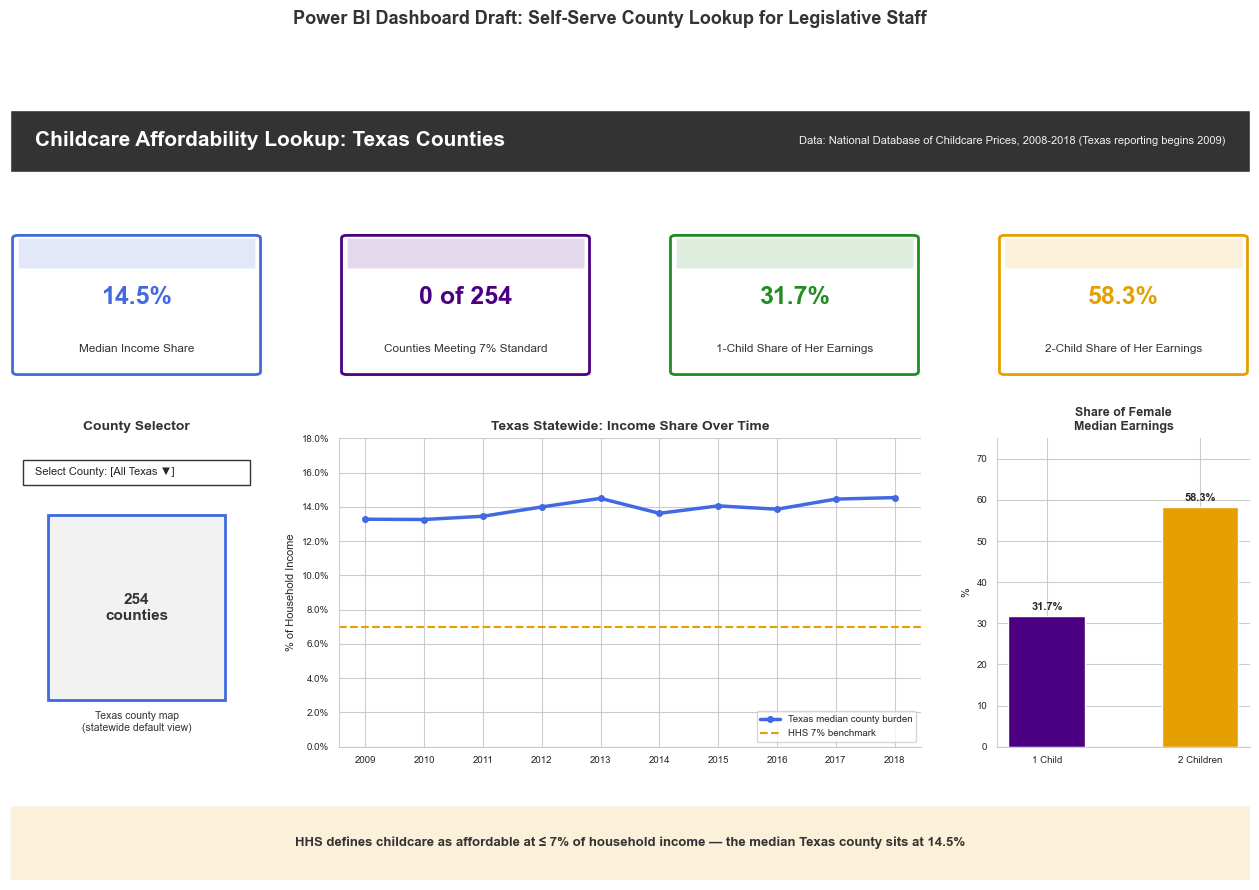

In [4]:
#Create visual
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(4, 4, height_ratios=[0.5, 1.2, 2.5, 0.6], hspace=0.4, wspace=0.3)

# Title bar
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_xlim(0, 1)
ax_title.set_ylim(0, 1)
ax_title.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor=DARK_GRAY))
ax_title.text(0.02, 0.5, 'Childcare Affordability Lookup: Texas Counties', ha='left', va='center',
              fontsize=15, fontweight='bold', color='white')
ax_title.text(0.98, 0.5, 'Data: National Database of Childcare Prices, 2008-2018 (Texas reporting begins 2009)',
              ha='right', va='center', fontsize=8, color=LIGHT_GRAY)
ax_title.axis('off')

# KPI strip - Texas statewide default view
kpis = [
    ('Median Income Share', f'{tx_median_share:.1f}%', ROYAL_BLUE),
    ('Counties Meeting 7% Standard', f'{tx_counties_below} of {tx_counties_total}', PURPLE),
    ('1-Child Share of Her Earnings', f'{tx_one_child:.1f}%', FOREST_GREEN),
    ('2-Child Share of Her Earnings', f'{tx_two_child:.1f}%', AMBER),
]
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, i])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(patches.FancyBboxPatch((0.03, 0.05), 0.94, 0.9, boxstyle='round,pad=0.02',
                                        facecolor='white', edgecolor=color, linewidth=2))
    ax.add_patch(patches.Rectangle((0.03, 0.75), 0.94, 0.2, facecolor=color, alpha=0.15))
    ax.text(0.5, 0.55, value, ha='center', va='center', fontsize=18, fontweight='bold', color=color)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=8.5, color=DARK_GRAY, wrap=True)
    ax.axis('off')

# County selector + map placeholder (left)
ax_selector = fig.add_subplot(gs[2, 0])
ax_selector.set_xlim(0, 1)
ax_selector.set_ylim(0, 1)
ax_selector.add_patch(patches.Rectangle((0.05, 0.85), 0.9, 0.08, facecolor='white',
                                        edgecolor=DARK_GRAY, linewidth=1))
ax_selector.text(0.1, 0.89, 'Select County: [All Texas \u25bc]', ha='left', va='center', fontsize=8)
ax_selector.add_patch(patches.Rectangle((0.15, 0.15), 0.7, 0.6, facecolor=LIGHT_GRAY,
                                        edgecolor=ROYAL_BLUE, linewidth=2))
ax_selector.text(0.5, 0.45, '254\ncounties', ha='center', va='center', fontsize=11,
                 fontweight='bold', color=DARK_GRAY)
ax_selector.text(0.5, 0.08, 'Texas county map\n(statewide default view)',
                 ha='center', va='center', fontsize=7.5, color=DARK_GRAY)
ax_selector.set_title('County Selector', fontsize=10, fontweight='bold', color=DARK_GRAY)
ax_selector.axis('off')

# Trend panel - real Texas trend, honest 2009 start
ax_trend = fig.add_subplot(gs[2, 1:3])
ax_trend.plot(texas_trend.index, texas_trend.values, color=ROYAL_BLUE, linewidth=2.5,
              marker='o', markersize=4, label='Texas median county burden')
ax_trend.axhline(7, color=AMBER, linestyle='--', linewidth=1.5, label='HHS 7% benchmark')
ax_trend.set_title('Texas Statewide: Income Share Over Time', fontsize=10, fontweight='bold', color=DARK_GRAY)
ax_trend.set_ylabel('% of Household Income', fontsize=8)
ax_trend.set_ylim(0, 18)
ax_trend.set_xticks(texas_trend.index)
ax_trend.tick_params(labelsize=7)
ax_trend.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_trend.legend(fontsize=7, loc='lower right')
ax_trend.spines['top'].set_visible(False)
ax_trend.spines['right'].set_visible(False)

# Second-earner bar chart (right) - Texas values
ax_bar = fig.add_subplot(gs[2, 3])
bar_values = [tx_one_child, tx_two_child]
ax_bar.bar(['1 Child', '2 Children'], bar_values, color=[PURPLE, AMBER], width=0.5)
ax_bar.set_title('Share of Female\nMedian Earnings', fontsize=9, fontweight='bold', color=DARK_GRAY)
ax_bar.set_ylabel('%', fontsize=8)
ax_bar.set_ylim(0, 75)
ax_bar.tick_params(labelsize=7)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
for i, v in enumerate(bar_values):
    ax_bar.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

# Benchmark footer strip
ax_footer = fig.add_subplot(gs[3, :])
ax_footer.set_xlim(0, 1)
ax_footer.set_ylim(0, 1)
ax_footer.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor=AMBER, alpha=0.15))
ax_footer.text(0.5, 0.5, f'HHS defines childcare as affordable at \u2264 7% of household income \u2014 the median Texas county sits at {tx_median_share:.1f}%',
               ha='center', va='center', fontsize=9.5, color=DARK_GRAY, fontweight='bold')
ax_footer.axis('off')

fig.suptitle('Power BI Dashboard Draft: Self-Serve County Lookup for Legislative Staff',
             fontsize=13, fontweight='bold', color=DARK_GRAY, y=0.98)
plt.show()

<hr style="page-break-after: always;">

### **Medium 3: Infographic Draft**

The single-page structure from Milestone 2 is unchanged: hero statistic, three supporting stat blocks, simplified trend, call to action, and credibility footer. The trend section now plots the corrected income-share series from the data preparation cell rather than sketched values, drawn to a real scale with the benchmark line placed accurately.

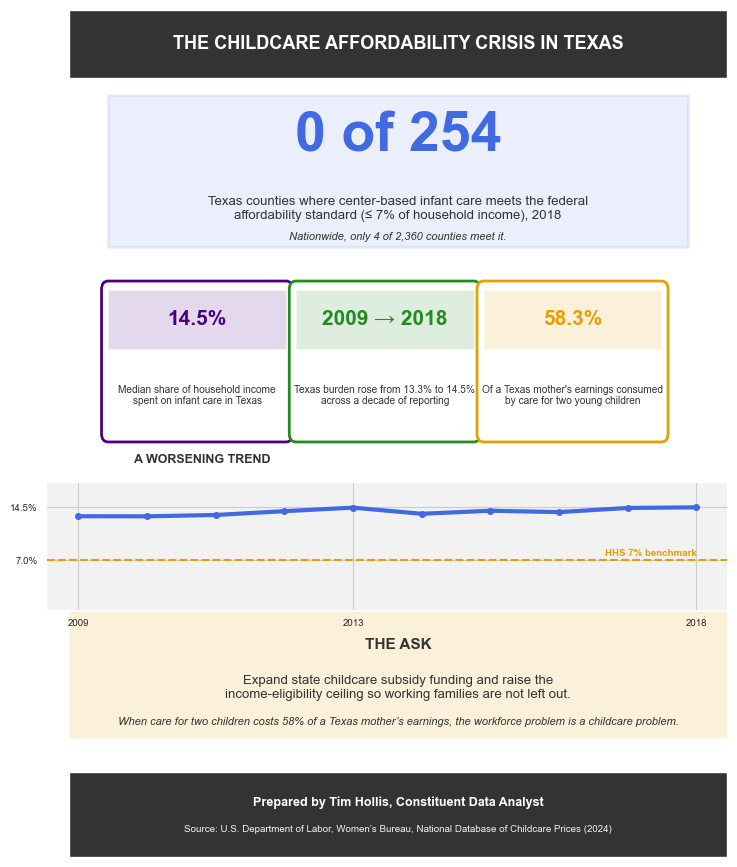

In [5]:
#Create infographic 
fig, ax = plt.subplots(figsize=(8.5, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Header band
ax.add_patch(patches.Rectangle((0, 0.92), 1, 0.08, facecolor=DARK_GRAY))
ax.text(0.5, 0.96, 'THE CHILDCARE AFFORDABILITY CRISIS IN TEXAS', ha='center', va='center',
        fontsize=13, fontweight='bold', color='white')

# Hero stat - the Texas shutout, with national scale proof beneath
ax.add_patch(patches.Rectangle((0.06, 0.72), 0.88, 0.18, facecolor=ROYAL_BLUE, alpha=0.1,
                               edgecolor=ROYAL_BLUE, linewidth=2))
ax.text(0.5, 0.85, f'{tx_counties_below} of {tx_counties_total}', ha='center', va='center',
        fontsize=40, fontweight='bold', color=ROYAL_BLUE)
ax.text(0.5, 0.765, 'Texas counties where center-based infant care meets the federal\naffordability standard (\u2264 7% of household income), 2018',
        ha='center', va='center', fontsize=9.5, color=DARK_GRAY)
ax.text(0.5, 0.732, f'Nationwide, only {counties_below} of {counties_total:,} counties meet it.',
        ha='center', va='center', fontsize=8, style='italic', color=DARK_GRAY)

# Three supporting stat blocks - Texas values
stats = [
    (f'{tx_median_share:.1f}%', 'Median share of household income\nspent on infant care in Texas', PURPLE),
    ('2009 \u2192 2018', f'Texas burden rose from {texas_trend.loc[2009]:.1f}% to {texas_trend.loc[2018]:.1f}%\nacross a decade of reporting', FOREST_GREEN),
    (f'{tx_two_child:.1f}%', "Of a Texas mother's earnings consumed\nby care for two young children", AMBER),
]
box_w = 0.27
for i, (stat, label, color) in enumerate(stats):
    x0 = 0.06 + i * (box_w + 0.015)
    ax.add_patch(patches.FancyBboxPatch((x0, 0.5), box_w, 0.17, boxstyle='round,pad=0.01',
                                        facecolor='white', edgecolor=color, linewidth=2))
    ax.add_patch(patches.Rectangle((x0, 0.6), box_w, 0.07, facecolor=color, alpha=0.15))
    ax.text(x0 + box_w / 2, 0.635, stat, ha='center', va='center', fontsize=15,
            fontweight='bold', color=color)
    ax.text(x0 + box_w / 2, 0.545, label, ha='center', va='center', fontsize=7.3, color=DARK_GRAY)

# Trend section - real Texas series on an inset axes with a true scale
ax.text(0.1, 0.465, 'A WORSENING TREND', fontsize=9, fontweight='bold', color=DARK_GRAY)
ax_trend = fig.add_axes([0.1, 0.335, 0.8, 0.115])
ax_trend.plot(texas_trend.index, texas_trend.values, color=ROYAL_BLUE, linewidth=3, marker='o', markersize=4)
ax_trend.axhline(7, color=AMBER, linestyle='--', linewidth=1.5)
ax_trend.text(2018, 7.6, 'HHS 7% benchmark', ha='right', fontsize=7,
              color=AMBER, fontweight='bold')
ax_trend.set_ylim(0, 18)
ax_trend.set_xticks([2009, 2013, 2018])
ax_trend.set_yticks([7, texas_trend.loc[2018]])
ax_trend.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_trend.tick_params(labelsize=7)
ax_trend.set_facecolor(LIGHT_GRAY)
for spine in ax_trend.spines.values():
    spine.set_visible(False)

# Call to action strip
ax.add_patch(patches.Rectangle((0, 0.14), 1, 0.15, facecolor=AMBER, alpha=0.15))
ax.text(0.5, 0.245, 'THE ASK', ha='center', fontsize=11, fontweight='bold', color=DARK_GRAY)
ax.text(0.5, 0.2, 'Expand state childcare subsidy funding and raise the\nincome-eligibility ceiling so working families are not left out.',
        ha='center', va='center', fontsize=9.5, color=DARK_GRAY)
ax.text(0.5, 0.16, f'When care for two children costs {tx_two_child:.0f}% of a Texas mother\u2019s earnings, the workforce problem is a childcare problem.',
        ha='center', va='center', fontsize=8, style='italic', color=DARK_GRAY)

# Footer / credibility line
ax.add_patch(patches.Rectangle((0, 0), 1, 0.1, facecolor=DARK_GRAY))
ax.text(0.5, 0.06, 'Prepared by Tim Hollis, Constituent Data Analyst', ha='center', fontsize=9,
        color='white', fontweight='bold')
ax.text(0.5, 0.03, 'Source: U.S. Department of Labor, Women\u2019s Bureau, National Database of Childcare Prices (2024)',
        ha='center', fontsize=7, color=LIGHT_GRAY)

plt.show()

<hr style="page-break-after: always;">

### **Design Narrative**

All three mediums share one colorblind-safe palette: royal blue for primary data, amber reserved exclusively for the HHS 7% benchmark, purple and forest green for supporting statistics, and dark gray for text. Keeping amber tied to a single meaning lets the benchmark line act as a visual anchor a viewer can track across the deck, the dashboard, and the infographic without relearning the color language. Slide titles are written as complete claims rather than topic labels, at 22 point against 12 to 15 point body text, so each slide's argument survives being forwarded in isolation. Charts use generous margins and a fixed title bar so the layout stays identical from slide to slide, and axis labels sit clear of the source footer.

The most consequential design decision in this draft was scoping statistics to their medium. The deck builds a national case before localizing, so its charts carry national figures. The dashboard and infographic are Texas artifacts for a Texas audience, so every headline number is a Texas value, led by the hero statistic that zero of 254 Texas counties meet the federal affordability standard. Mixing scopes in early drafts produced two versions of the second-earner figure, 61.1% national and 58.3% Texas, and resolving that inconsistency mattered more to credibility than any aesthetic choice. Finally, the visuals are honest about coverage: Texas reporting begins in 2009, so its trend line starts there and says so, and the infographic trend is drawn on a true zero-based scale so the gap above the benchmark is not exaggerated.

# Reflection for Week 6

## General Reflection
This milestone felt like the moment the project finally came to life. Moving from mock-ups to data-driven drafts changed the entire feel of the three mediums. Once I loaded the childcare dataset and built the shared statistics cell, everything became more grounded and consistent. The Texas-first framing worked even better with real numbers, especially the fact that zero Texas counties meet the federal 7 percent affordability standard. Designing the PowerPoint deck, dashboard, and infographic with actual values made the story clearer and more urgent. The biggest shift this week was seeing how the visuals communicate differently once the data is real, and how important it is to keep the tone, spacing, and color choices aligned across all three mediums.

## Straightforward Aspects
- The shared statistics cell made the workflow smooth because every medium pulled from the same numbers.
- The colorblind-safe palette from Milestone 2 translated well into the final drafts and kept everything visually consistent.
- The Texas-first narrative structure worked naturally once the statewide and Bexar County values were calculated.
- The PowerPoint slide templates were easy to update with real charts since the layout was already established.
- The infographic design flowed well once the hero statistic and supporting blocks were populated with actual data.

## Challenging Aspects
- The dataset is extremely wide, so selecting and renaming only the fields needed for the story required careful filtering.
- Texas reporting begins in 2009, which forced adjustments to the trend visuals so they honestly reflect the missing early years.
- The affordability distribution chart was visually tricky because only four counties nationwide meet the standard, which creates a long right tail and a very small left cluster.
- Balancing text density across the three mediums took time, especially making sure the Power BI draft did not feel overcrowded.
- Ensuring that the infographic’s trend inset remained readable at a small scale required several passes on spacing and tick choices.

